In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [ ]:
df1 = pd.read_csv('full_history.csv')
df1

,commit,experiment,loc_f1,dmg_f1,composite,memory_gb,status,steps,description
0,404c628,1.0,NaN,NaN,0.1467,19.9,keep,NaN,baseline U-Net dual-head batch=12 TIME_BUDGET=...
1,315834b,2.0,NaN,NaN,0.2867,19.9,keep,NaN,increase TIME_BUDGET 120s->900s
2,c8f128a,3.0,NaN,NaN,0.3003,19.9,keep,NaN,OneCycleLR base_lr=1e-3 max_lr=3e-3
3,7ca2117,NaN,NaN,0.310,NaN,NaN,discard,NaN,"SE blocks to DoubleConv (channel attention), r..."
4,d60d387,4.0,NaN,0.270,0.3111,19.9,keep,NaN,class-weighted CE for damage head weights=[0.5...
5,3d84c26,NaN,NaN,0.310,NaN,NaN,discard,NaN,"SE blocks + batch=8, reset — 0.310 < 0.311 thr..."
6,a15921c,NaN,NaN,0.311,NaN,NaN,discard,NaN,masked multi-class Dice loss for damage + loss...
7,cce718f,NaN,NaN,0.311,NaN,NaN,discard,NaN,dedicated damage conv block + class-weighted C...
8,32f6c5b,NaN,NaN,0.302,NaN,NaN,discard,NaN,Focal Loss + extra augmentations + cudnn bench...
9,94d6a49,NaN,NaN,0.310,NaN,NaN,discard,NaN,"batch=8 + 1.25x capacity f1=40..f5=640, reset ..."


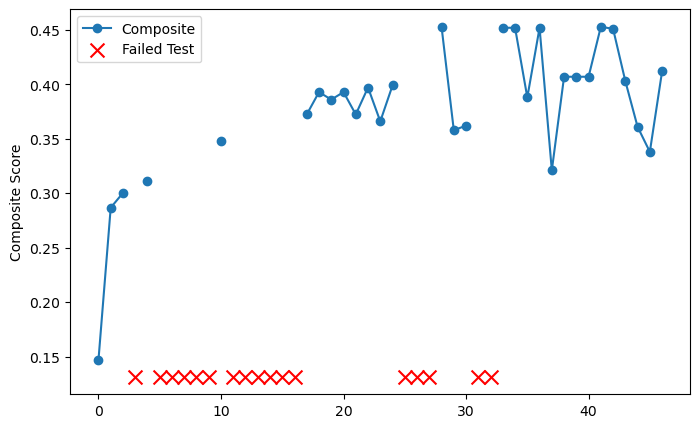

In [42]:
fig, ax = plt.subplots(figsize=(8, 5))

# Plot valid values
ax.plot(df1.index, df1['composite'], marker='o', label='Composite')

# Find failures
failed = df1['composite'].isna()

# Put failure markers slightly below the data range
y_fail = df1['composite'].min() - 0.05 * (
    df1['composite'].max() - df1['composite'].min()
)
    
ax.scatter(
    df1.index[failed],
    [y_fail] * failed.sum(),
    marker='x',
    c='r',
    s=100,
    label='Failed Test'
)

ax.legend()
ax.set_ylabel("Composite Score")
plt.show()

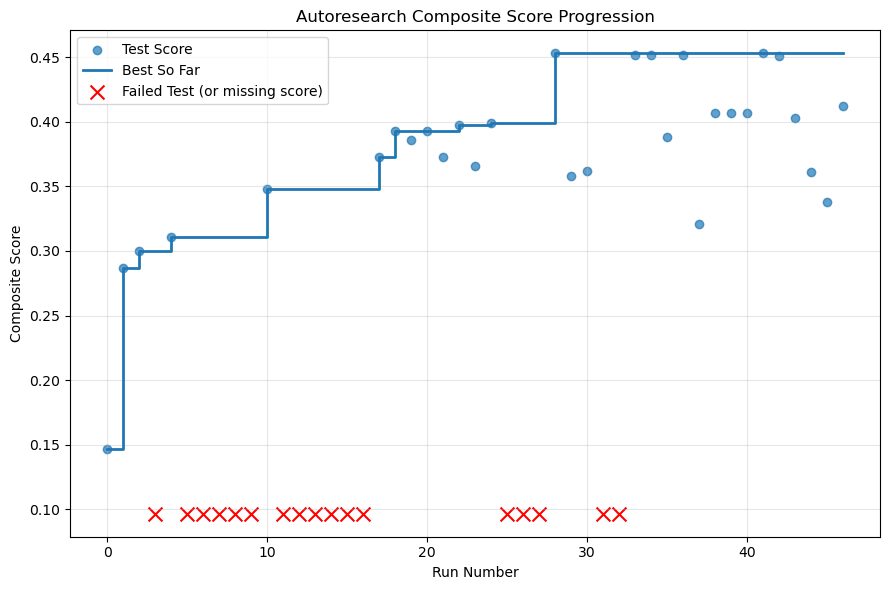

In [43]:
scores = df1['composite']

# Running best, ignoring NaNs
running_best = scores.ffill().cummax()

fig, ax = plt.subplots(figsize=(9, 6))

# Actual scores
ax.scatter(
    df1.index,
    scores,
    alpha=0.7,
    label="Test Score"
)

# Best-so-far line
ax.step(
    df1.index,
    running_best,
    where='post',
    linewidth=2,
    label="Best So Far"
)

# Failed tests
failed = scores.isna()

ax.scatter(
    df1.index[failed],
    [running_best.min() - 0.05] * failed.sum(),
    marker='x',
    c='r',
    s=100,
    label='Failed Test (or missing score)'
)

ax.set_title("Autoresearch Composite Score Progression")
ax.set_xlabel("Run Number")
ax.set_ylabel("Composite Score")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

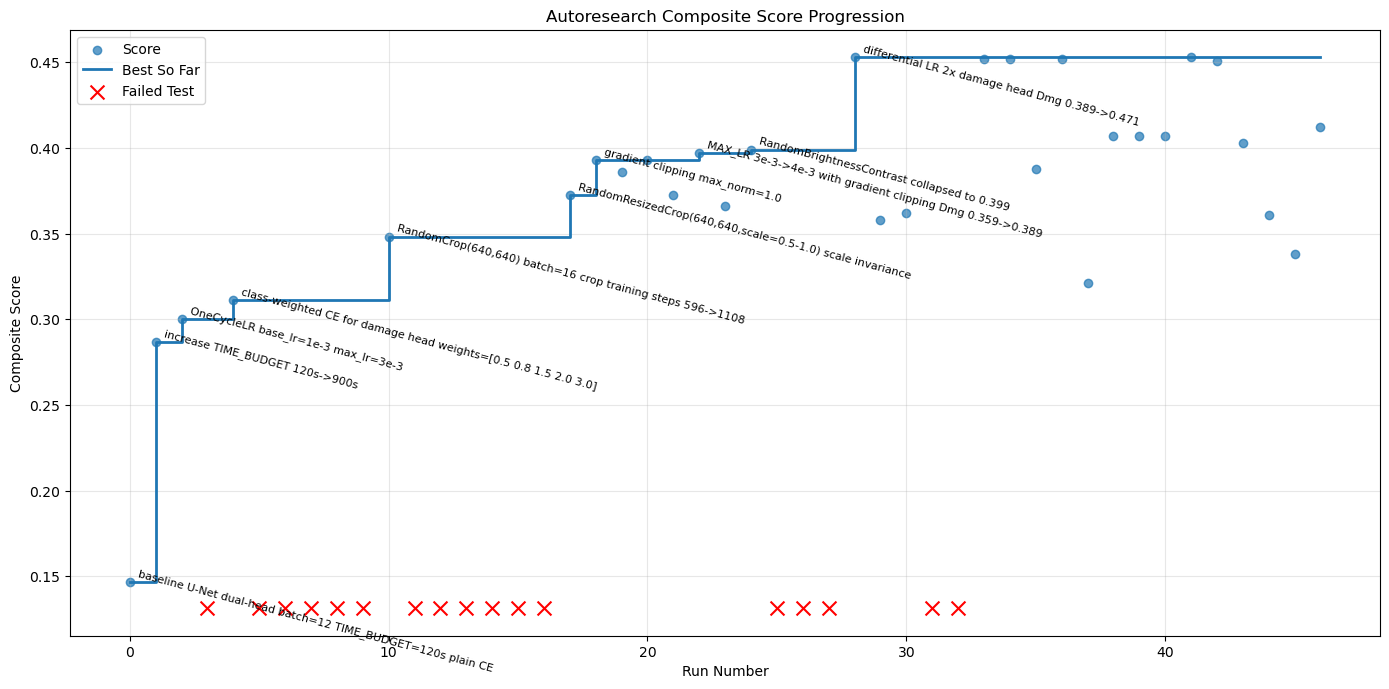

In [39]:
scores = df1["composite"]

# Running best while ignoring NaNs
running_best = scores.ffill().cummax()

# Identify runs that established a new best
improvements = running_best.diff().fillna(np.inf) > 0

# Ensure first valid score is labeled
first_valid = scores.first_valid_index()
if first_valid is not None:
    improvements.loc[first_valid] = True

fig, ax = plt.subplots(figsize=(14, 7))

# Plot all successful scores
ax.scatter(
    df1.index[~scores.isna()],
    scores[~scores.isna()],
    alpha=0.7,
    label="Score"
)

# Plot best-so-far line
ax.step(
    df1.index,
    running_best,
    where="post",
    linewidth=2,
    label="Best So Far"
)

# Plot failed tests as red X's
failed = scores.isna()

if failed.any():
    score_range = scores.max() - scores.min()

    if score_range == 0:
        score_range = 1

    fail_y = scores.min() - score_range * 0.05

    ax.scatter(
        df1.index[failed],
        [fail_y] * failed.sum(),
        color="red",
        marker="x",
        s=100,
        label="Failed Test"
    )

# Annotate improvements only
for idx in df1.index[improvements]:
    if pd.notna(scores.loc[idx]):
        label = str(df1.loc[idx, "description"]).strip()

        ax.annotate(
            label,
            (idx, scores.loc[idx]),
            fontsize=8,
            rotation=-15,
            xytext=(5, 10),
            textcoords="offset points",
            ha="left",
            va="top"
        )

ax.set_title("Autoresearch Composite Score Progression")
ax.set_xlabel("Run Number")
ax.set_ylabel("Composite Score")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()